In [217]:
%run "BlackjackSetup_Buffer.ipynb"

In [ ]:
# Setting up LinUCB w/Episode Buffer

import numpy as np
import matplotlib.pyplot as plt

def compute_ucb(x, A, b, alpha):
    UCB = []
    for i in range(len(b)):
        Ainv = np.linalg.inv(A[i])
        Rhat = x @ Ainv @ b[i] 
        Uhat = alpha * np.sqrt(x.T @ Ainv @ x)
        UCB.append(Rhat+Uhat)
    return np.array(UCB)

tenv = BlackjackTable()

def linucb_deck_aware(alpha, trials, gamma=0.9):
    K = 2  # Stand / Hit
    d = 39 # Features
    A = [np.eye(d+1) for i in range(K)]
    b = [np.zeros(d+1) for i in range(K)]

    for n in range(trials):
        tenv.reset()
        game_terminated = False
        
        while not game_terminated:
            obs, reward, game_terminated, _, info = tenv.step((0, 1)) # initial bet
            if game_terminated: break
            
            if info['hand_done']:
                continue
            
            hand_buffer = []
            hand_over = False
            
            while not hand_over and not game_terminated:
                # context vector
                player = interprethand(obs['playercards'])
                dealer = interprethand(obs['dealercards'])
                prev_cards = interprethand(obs['pastcards']) # Cards seen so far in deck
                x = np.concatenate((np.array([1]), prev_cards, player, dealer))

                # selecting action
                UCB = compute_ucb(x, A, b, alpha)
                idx = np.argmax(UCB)

                # taking step
                obs, reward, game_terminated, _, info = tenv.step((1, idx))
                hand_over = info['hand_done']

                hand_buffer.append((x, idx))

                # updates using terminal reward
                if hand_over:
                    final_payout = reward 
                    # Backpropagate the payout to all actions in the buffer
                    for i, (state_x, action_idx) in enumerate(reversed(hand_buffer)):
                        # Applying a discount factor (gamma) helps attribute 
                        # more weight to the final decision.
                        discounted_reward = final_payout * (gamma ** i)
                        A[action_idx] += np.outer(state_x, state_x)
                        b[action_idx] += discounted_reward * state_x
                        
    return A, b

Generating Betas

In [ ]:
A, b = linucb_deck_aware(0.1, 20000, 0.9)
betas = np.zeros((len(b), len(b[0])))

for i in range(len(b)):
    Ainv = np.linalg.inv(A[i])
    beta = Ainv @ b[i]
    betas[i] = beta

plt.imshow(betas[0, 1:].reshape(3, 13))
plt.colorbar()
plt.title('LinUCB Estimated Coefficients for Stand Action')
plt.show()
plt.imshow(betas[1, 1:].reshape(3, 13))
plt.colorbar()
plt.title('LinUCB Estimated Coefficients for Hit Action')
plt.show()

### Tests to see what varies

In [ ]:
test = False

gammas = [0.7, 0.9, 0.99]
alphas = [0.05, 0.1, 0.2]
trials = [1000, 5000, 10000]
opp = np.arange(13)

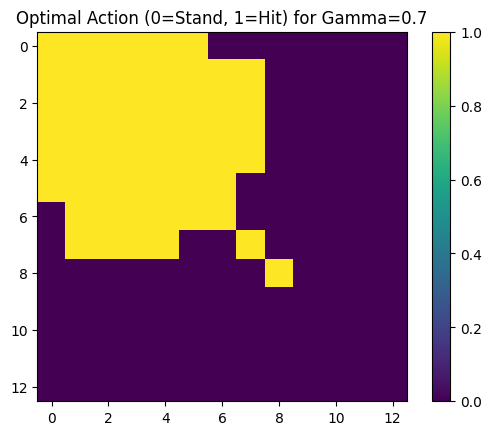

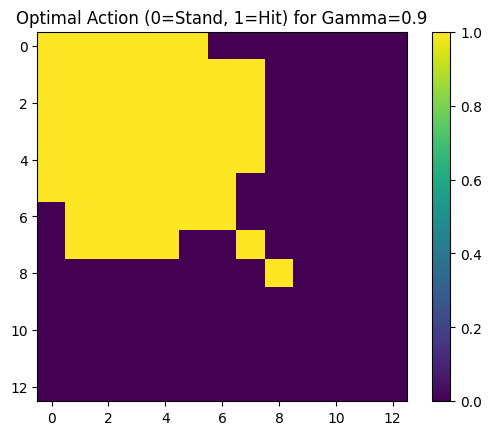

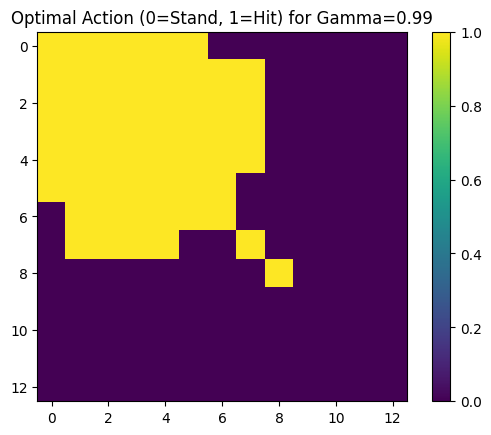

In [220]:
# gammas
if test:
    for g in gammas:
        results = linucb_deck_aware(0.1, 5000, gamma=g)
        A, b = results
        for i in range(len(b)):
            Ainv = np.linalg.inv(A[i])
            beta = Ainv @ b[i]

        opt_action = np.zeros((13,13), dtype=int)
        for i in range(13):
            for j in range(13):
                prev = np.zeros(13)
                player = np.zeros(13)
                dealer = np.zeros(13)

                player[i] = 1
                player[j] = 1
                dealer[6] = 1

                x = np.concatenate((np.array([1]), prev, player, dealer))

                reward = betas @ x
                opt_action[i,j] = np.argmax(reward)
        
        plt.title(f'Optimal Action (0=Stand, 1=Hit) for Gamma={g}')
        plt.imshow(opt_action)
        plt.colorbar()
        plt.show()

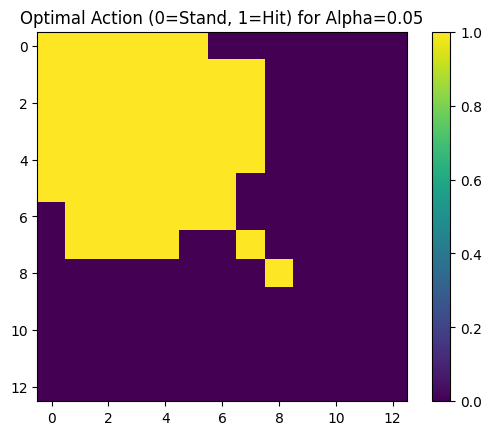

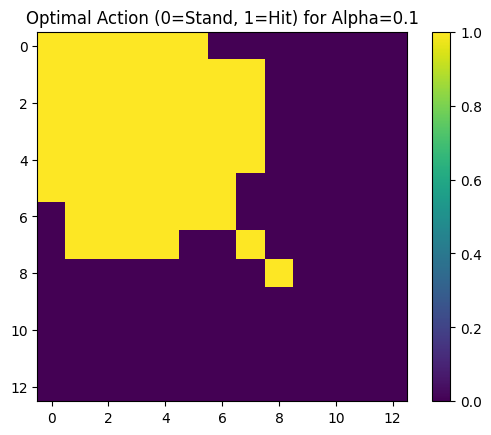

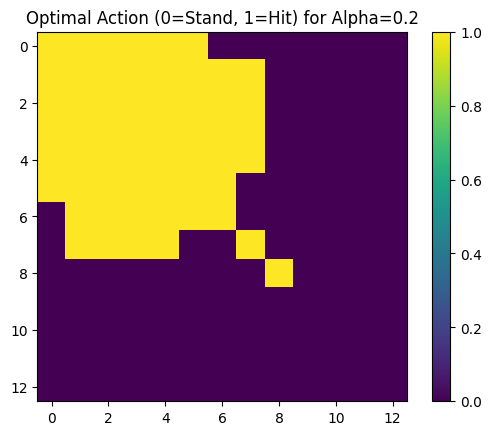

In [ ]:
# alphas

if test:
    for a in alphas:
        results = linucb_deck_aware(a, 5000, gamma=0.9)
        A, b = results
        for i in range(len(b)):
            Ainv = np.linalg.inv(A[i])
            beta = Ainv @ b[i]

        opt_action = np.zeros((13,13), dtype=int)
        for i in range(13):
            for j in range(13):
                prev = np.zeros(13)
                player = np.zeros(13)
                dealer = np.zeros(13)

                player[i] = 1
                player[j] = 1
                dealer[6] = 1

                x = np.concatenate((np.array([1]), prev, player, dealer))

                reward = betas @ x
                opt_action[i,j] = np.argmax(reward)
        
        plt.title(f'Optimal Action (0=Stand, 1=Hit) for Alpha={a}')
        plt.imshow(opt_action)
        plt.colorbar()
        plt.show()

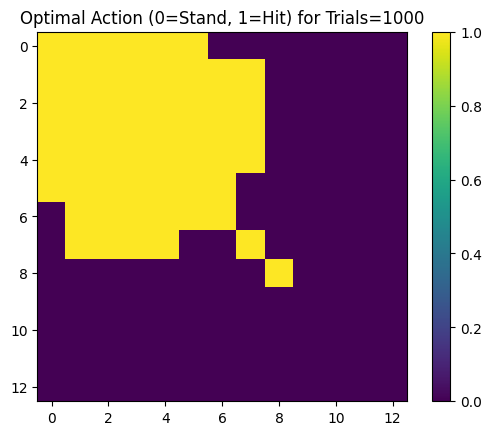

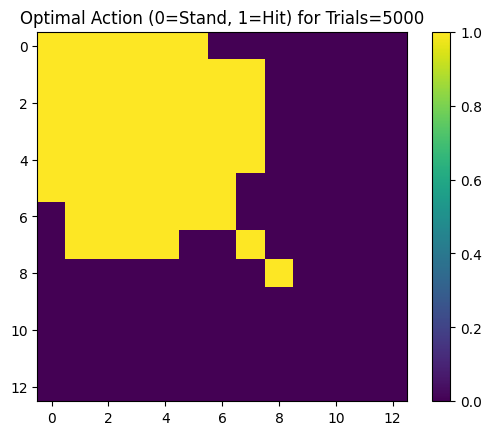

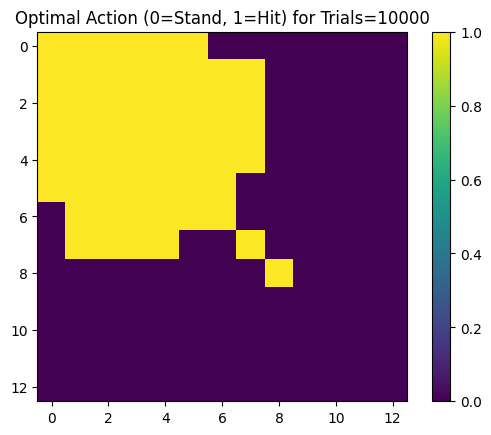

In [ ]:
# trials
if test:
    for t in trials:
        results = linucb_deck_aware(0.1, t, gamma=0.9)
        A, b = results
        for i in range(len(b)):
            Ainv = np.linalg.inv(A[i])
            beta = Ainv @ b[i]

        opt_action = np.zeros((13,13), dtype=int)
        for i in range(13):
            for j in range(13):
                prev = np.zeros(13)
                player = np.zeros(13)
                dealer = np.zeros(13)

                player[i] = 1
                player[j] = 1
                dealer[6] = 1

                x = np.concatenate((np.array([1]), prev, player, dealer))

                reward = betas @ x
                opt_action[i,j] = np.argmax(reward)
        
        plt.title(f'Optimal Action (0=Stand, 1=Hit) for Trials={t}')
        plt.imshow(opt_action)
        plt.colorbar()
        plt.show()

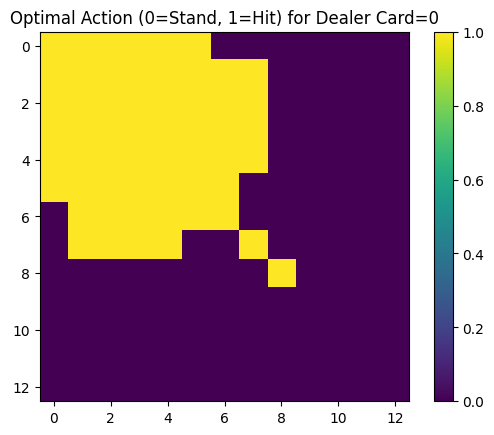

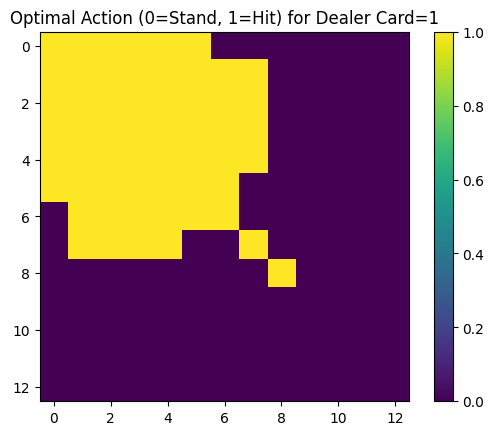

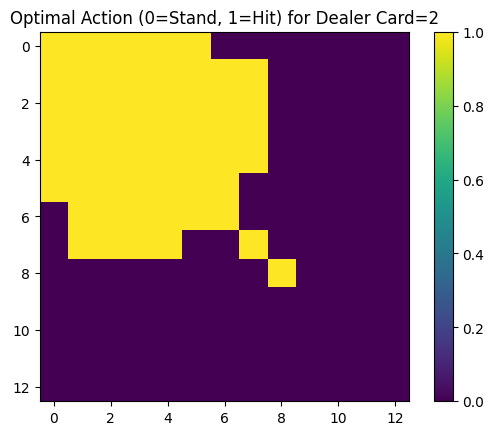

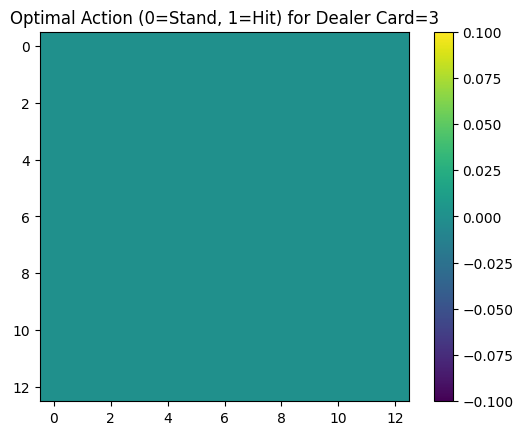

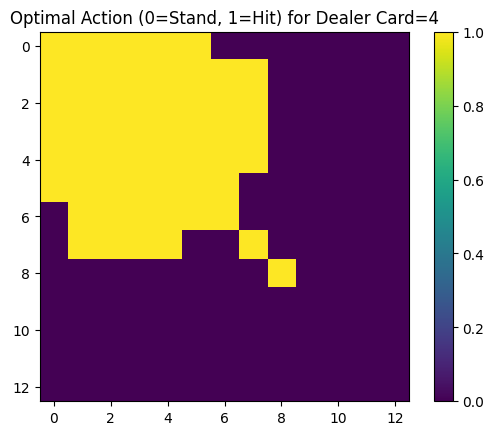

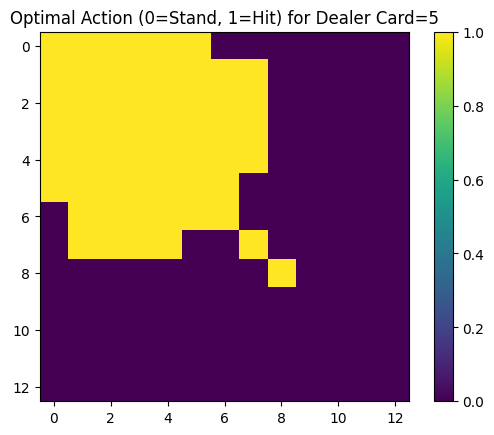

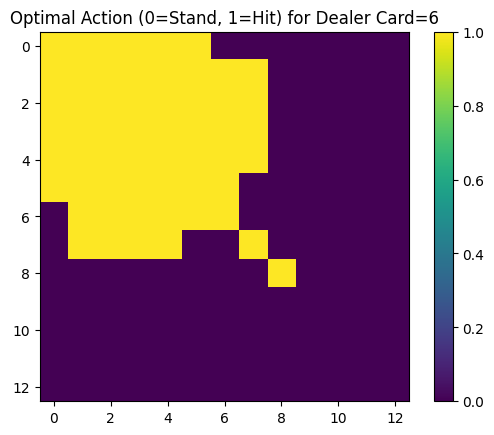

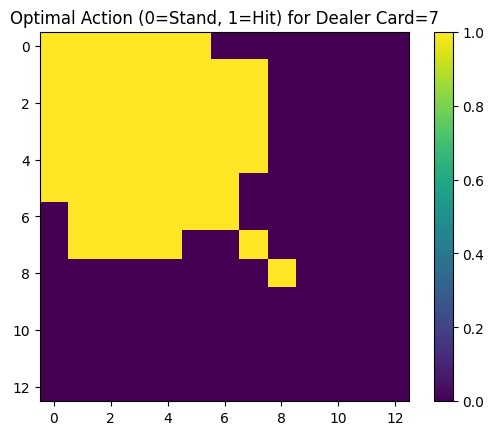

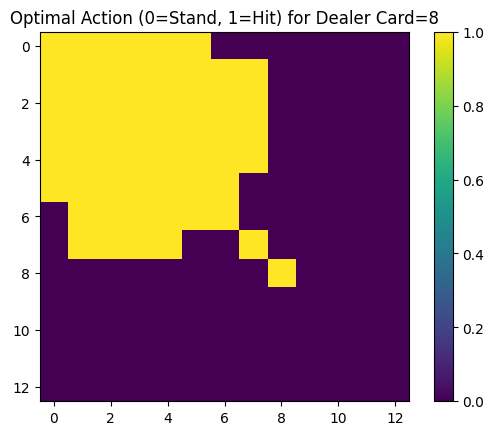

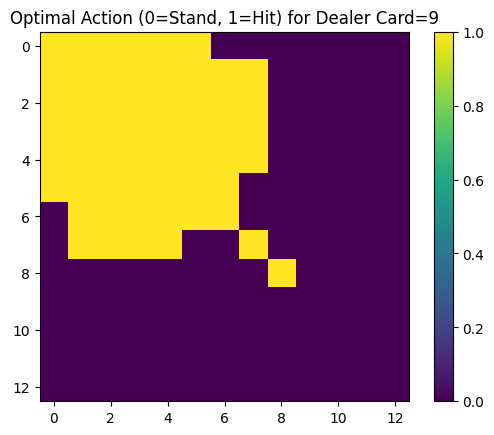

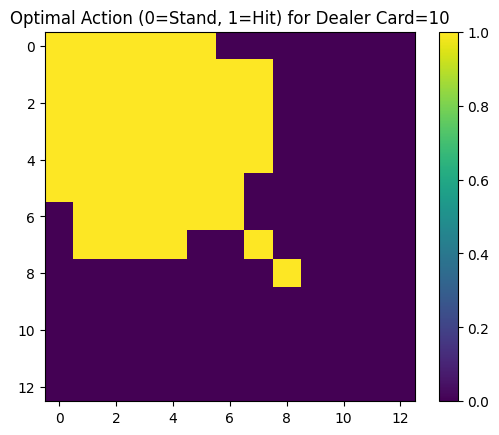

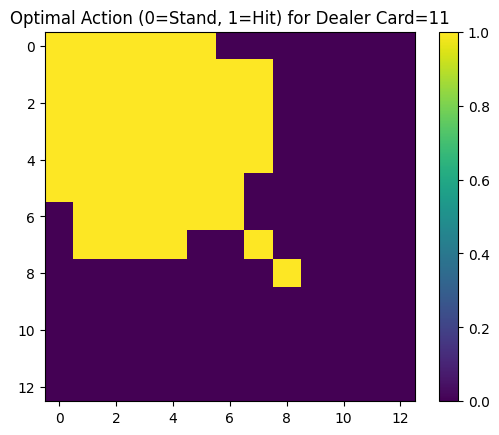

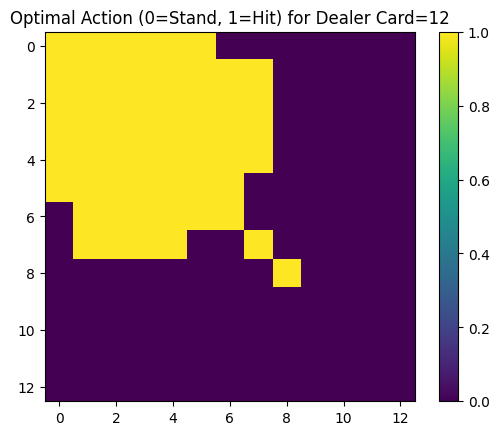

In [223]:
# dealer card
if test:
    for o in opp:
        results = linucb_deck_aware(0.1, 5000, gamma=0.9)
        A, b = results
        for i in range(len(b)):
            Ainv = np.linalg.inv(A[i])
            beta = Ainv @ b[i]

        opt_action = np.zeros((13,13), dtype=int)
        for i in range(13):
            for j in range(13):
                prev = np.zeros(13)
                player = np.zeros(13)
                dealer = np.zeros(13)

                player[i] = 1
                player[j] = 1
                dealer[o] = 1

                x = np.concatenate((np.array([1]), prev, player, dealer))

                reward = betas @ x
                opt_action[i,j] = np.argmax(reward)
        
        plt.title(f'Optimal Action (0=Stand, 1=Hit) for Dealer Card={o+1}')
        plt.imshow(opt_action)
        plt.colorbar()
        plt.show()